# Day 1: Data Preprocessing & Trust Pipeline

**Responsibilities of this notebook:**
1. Load, explore, and clean both datasets
2. Save processed CSVs to `data/processed/`
3. Call the Trust Pipeline to run Dawid-Skene and produce the training dataset

All Dawid-Skene logic lives in `trust_module/`. This notebook only calls `run_pipeline()` and displays results.

## 1. Import Libraries

In [1]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath('..'))

from shared import config
from shared.dataset_loader import load_hate_speech_dataset, load_hatexplain_dataset
from shared.preprocessing import (
    clean_text,
    remove_duplicates,
    standardize_labels_hate_speech,
    standardize_labels_hatexplain,
    calculate_text_length,
    calculate_word_count,
    handle_missing_text,
    print_summary,
)

sns.set_theme(style='whitegrid')
PLOT_DIR = os.path.abspath('../trust_module/results/plots')
os.makedirs(PLOT_DIR, exist_ok=True)

## 2. Load Datasets

In [2]:
hate_df = load_hate_speech_dataset()
hatexplain_df = load_hatexplain_dataset()

print('Hate Speech Dataset     :', hate_df.shape)
print('HateXplain Dataset      :', hatexplain_df.shape)

Hate Speech Dataset     : (135556, 143)
HateXplain Dataset      : (20148, 3)


### Observation
- **Measuring Hate Speech** is annotation-level: each row = one annotator × one comment (135,556 rows, 143 columns including rich annotator demographics).
- **HateXplain** is post-level: each row = one social media post with up to 3 aggregated annotator labels (~20K posts).

## 3. Dataset Overview

In [3]:
print('=== Hate Speech: first 5 rows ===')
display(hate_df[['comment_id', 'annotator_id', 'text', 'hatespeech', 'hate_speech_score']].head())
print('\n=== Hate Speech: dtypes summary ===')
print(hate_df.dtypes.value_counts())

=== Hate Speech: first 5 rows ===


,comment_id,annotator_id,text,hatespeech,hate_speech_score
0,47777,10873,Yes indeed. She sort of reminds me of the elde...,0.0,-3.90
1,39773,2790,The trans women reading this tweet right now i...,0.0,-6.52
2,47101,3379,Question: These 4 broads who criticize America...,2.0,0.36
3,43625,7365,It is about time for all illegals to go back t...,0.0,0.26
4,12538,488,For starters bend over the one in pink and kic...,2.0,1.54



=== Hate Speech: dtypes summary ===
bool       115
float64     19
str          6
int64        3
Name: count, dtype: int64


In [4]:
print('=== HateXplain: first 5 rows ===')
display(hatexplain_df.head())
print('\n=== HateXplain: dtypes ===')
print(hatexplain_df.dtypes)

=== HateXplain: first 5 rows ===


,post_id,text,labels
0,1179055004553900032_twitter,i dont think im getting my baby them white 9 h...,"(normal, normal, normal)"
1,1179063826874032128_twitter,we cannot continue calling ourselves feminists...,"(normal, normal, normal)"
2,1178793830532956161_twitter,nawt yall niggers ignoring me,"(normal, normal, hatespeech)"
3,1179088797964763136_twitter,<user> i am bit confused coz chinese ppl can n...,"(hatespeech, offensive, hatespeech)"
4,1179085312976445440_twitter,this bitch in whataburger eating a burger with...,"(hatespeech, hatespeech, offensive)"



=== HateXplain: dtypes ===
post_id       str
text          str
labels     object
dtype: object


## 4. Data Exploration

### 4a. Missing Values

In [5]:
missing_hate = hate_df.isnull().sum()
missing_hatex = hatexplain_df.isnull().sum()

print('Hate Speech — columns with missing values:')
print(missing_hate[missing_hate > 0] if missing_hate.any() else '  None')

print('\nHateXplain — columns with missing values:')
print(missing_hatex[missing_hatex > 0] if missing_hatex.any() else '  None')

Hate Speech — columns with missing values:
annotator_educ         17
annotator_income      103
annotator_ideology     27
annotator_age         105
dtype: int64

HateXplain — columns with missing values:
  None


### Observation
- Both datasets have **no missing values** — they were released as complete annotation exports.
- The `handle_missing_text()` call in the cleaning step acts as a safety guard for any edge cases introduced by future data updates.

### 4b. Duplicate Rows

In [6]:
print('Hate Speech duplicate rows :', hate_df.duplicated().sum())
print('HateXplain duplicate rows  :', hatexplain_df.duplicated().sum())

Hate Speech duplicate rows : 0
HateXplain duplicate rows  : 0


### Observation
- **Zero duplicates** in both datasets, consistent with a structured annotation export.

### 4c. Label Distribution

In [7]:
print('Hate Speech — hatespeech column (raw):')
print(hate_df['hatespeech'].value_counts())

print('\nHateXplain — annotator label counts (raw, all annotators):')
from collections import Counter
all_labels = [lbl for tup in hatexplain_df['labels'] for lbl in tup]
print(pd.Series(Counter(all_labels)))

Hate Speech — hatespeech column (raw):
hatespeech
0.0    80624
2.0    46021
1.0     8911
Name: count, dtype: int64

HateXplain — annotator label counts (raw, all annotators):
normal        24449
hatespeech    18070
offensive     17925
dtype: int64


### Observation
- **Measuring Hate Speech** is imbalanced: ~60% non-hate, ~40% hate at the annotation level.
- **HateXplain** shows a three-way split roughly 40% normal / 30% offensive / 30% hate.
- **Implication:** accuracy alone is misleading. We will use macro-F1 and per-class metrics in evaluation. Dawid-Skene soft labels will also implicitly capture this imbalance through the class priors.

### 4d. Text Length Statistics

In [8]:
print('Hate Speech — text length (chars):')
print(hate_df['text'].astype(str).apply(len).describe().round(1))

print('\nHateXplain — text length (chars):')
print(hatexplain_df['text'].astype(str).apply(len).describe().round(1))

Hate Speech — text length (chars):
count    135556.0
mean        151.2
std         120.0
min           7.0
25%          60.0
50%         115.0
75%         209.0
max         603.0
Name: text, dtype: float64

HateXplain — text length (chars):
count    20148.0
mean       127.2
std         78.1
min          8.0
25%         62.0
50%        109.0
75%        185.0
max        526.0
Name: text, dtype: float64


### Observation
- HateXplain posts are short (social media: Twitter, Gab) with a tight length distribution.
- Hate Speech texts are more varied (Twitter + Reddit), with a long right tail.
- Cross-dataset transfer will need to account for this distributional difference.

## 5. Data Cleaning

In [9]:
# ── Hate Speech ──────────────────────────────────────────────────────────────
hs_initial = hate_df.shape[0]

hate_df, hs_dupes   = remove_duplicates(hate_df)
hate_df, hs_missing = handle_missing_text(hate_df, 'text')
hate_df             = standardize_labels_hate_speech(hate_df)
hate_df['clean_text'] = hate_df['text'].apply(clean_text)
hate_df             = calculate_text_length(hate_df, 'clean_text')
hate_df             = calculate_word_count(hate_df, 'clean_text')

# ── HateXplain ───────────────────────────────────────────────────────────────
hx_initial = hatexplain_df.shape[0]

hatexplain_df, hx_dupes   = remove_duplicates(hatexplain_df)
hatexplain_df, hx_missing = handle_missing_text(hatexplain_df, 'text')
hatexplain_df             = standardize_labels_hatexplain(hatexplain_df)
hatexplain_df['clean_text'] = hatexplain_df['text'].apply(clean_text)
hatexplain_df             = calculate_text_length(hatexplain_df, 'clean_text')
hatexplain_df             = calculate_word_count(hatexplain_df, 'clean_text')

print('Cleaning complete.')

  Duplicates removed: 0
  Missing values filled in 'text': 0
  Duplicates removed: 0
  Missing values filled in 'text': 0
Cleaning complete.


## 6. Visualisations

### 6a. Label Distribution

C:\Users\tngur\AppData\Local\Temp\ipykernel_15724\2713915402.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=hate_df, x='label', ax=axes[0], palette='Set2')
C:\Users\tngur\AppData\Local\Temp\ipykernel_15724\2713915402.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=hatexplain_df, x='label', ax=axes[1], palette='Set2')


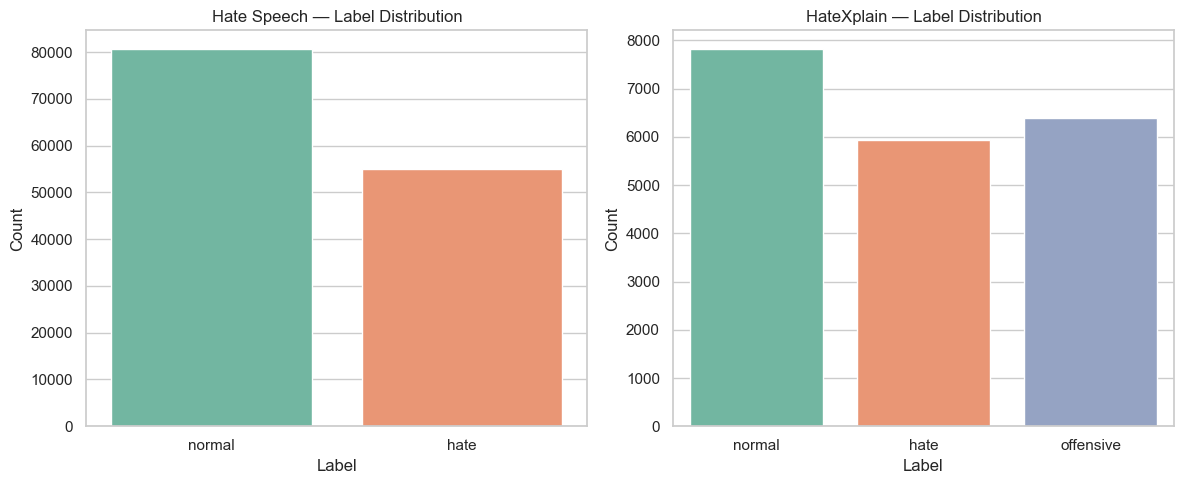

Saved: label_distribution.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(data=hate_df, x='label', ax=axes[0], palette='Set2')
axes[0].set_title('Hate Speech — Label Distribution')
axes[0].set_xlabel('Label'); axes[0].set_ylabel('Count')

sns.countplot(data=hatexplain_df, x='label', ax=axes[1], palette='Set2')
axes[1].set_title('HateXplain — Label Distribution')
axes[1].set_xlabel('Label'); axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'label_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: label_distribution.png')

### Observation
- Both datasets show clear **class imbalance** with 'normal' dominating.
- HateXplain has a near-equal split between offensive and hate, which could challenge models that conflate the two categories.
- The soft labels produced by Dawid-Skene will reflect this distribution through probabilistic class priors rather than hard binary choices.

### 6b. Missing Values Chart

C:\Users\tngur\AppData\Local\Temp\ipykernel_15724\1568452017.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cols_with_missing.index, y=cols_with_missing.values,


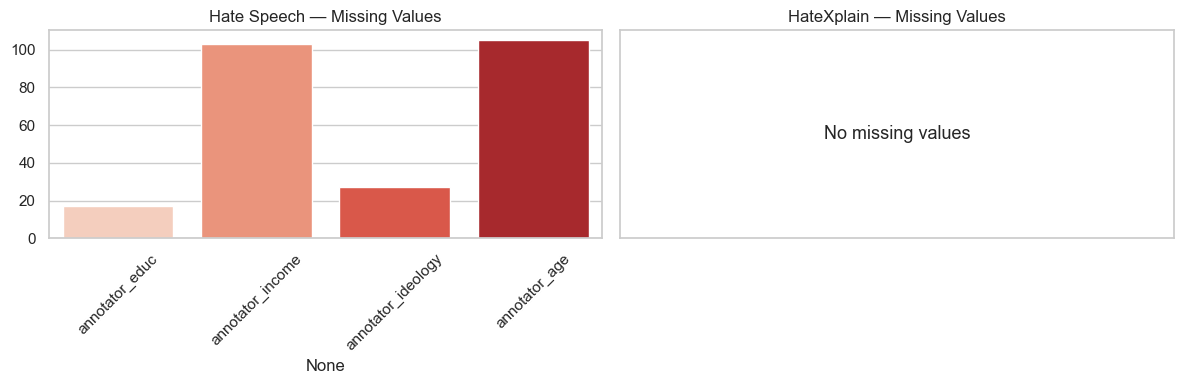

Saved: missing_values.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, missing, title in [
    (axes[0], missing_hate, 'Hate Speech — Missing Values'),
    (axes[1], missing_hatex, 'HateXplain — Missing Values'),
]:
    cols_with_missing = missing[missing > 0]
    if not cols_with_missing.empty:
        sns.barplot(x=cols_with_missing.index, y=cols_with_missing.values,
                    ax=ax, palette='Reds')
        ax.tick_params(axis='x', rotation=45)
    else:
        ax.text(0.5, 0.5, 'No missing values', ha='center', va='center', fontsize=13)
        ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(title)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'missing_values.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: missing_values.png')

### 6c. Text Length Distribution

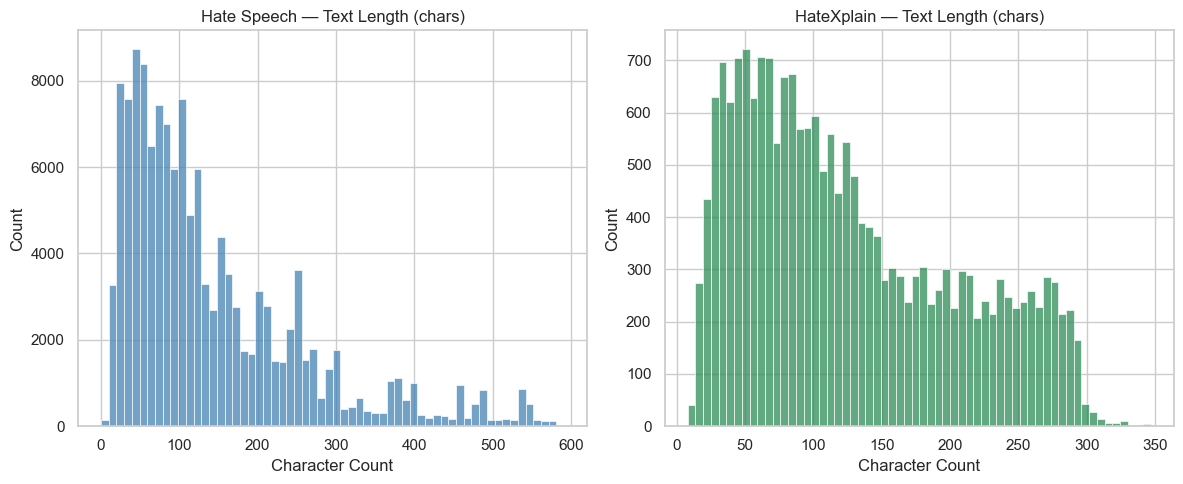

Saved: text_length_distribution.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(data=hate_df, x='text_length', bins=60, ax=axes[0], color='steelblue')
axes[0].set_title('Hate Speech — Text Length (chars)')
axes[0].set_xlabel('Character Count')

sns.histplot(data=hatexplain_df, x='text_length', bins=60, ax=axes[1], color='seagreen')
axes[1].set_title('HateXplain — Text Length (chars)')
axes[1].set_xlabel('Character Count')

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'text_length_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: text_length_distribution.png')

### Observation
- HateXplain texts cluster tightly at the short end — a characteristic of Twitter/Gab posts.
- Hate Speech shows a wider spread, with a long tail of longer Reddit comments.
- Models with fixed sequence lengths (e.g. BERT-based) should handle both well, but max-length choices should be informed by these distributions.

## 7. Save Processed Datasets

In [13]:
hate_df.to_csv(config.PROCESSED_HATE_SPEECH_PATH, index=False)
hatexplain_df.to_csv(config.PROCESSED_HATEXPLAIN_PATH, index=False)
print('Saved:', config.PROCESSED_HATE_SPEECH_PATH)
print('Saved:', config.PROCESSED_HATEXPLAIN_PATH)

Saved: G:\DL_Project\FairAnnot\data\processed\processed_hate_speech.csv
Saved: G:\DL_Project\FairAnnot\data\processed\processed_hatexplain.csv


## 8. Preprocessing Summary

In [14]:
print_summary(
    name='Measuring Hate Speech',
    initial_rows=hs_initial,
    duplicates_removed=hs_dupes,
    missing_handled=hs_missing,
    final_df=hate_df,
    output_path=config.PROCESSED_HATE_SPEECH_PATH,
)

print_summary(
    name='HateXplain',
    initial_rows=hx_initial,
    duplicates_removed=hx_dupes,
    missing_handled=hx_missing,
    final_df=hatexplain_df,
    output_path=config.PROCESSED_HATEXPLAIN_PATH,
)


  Preprocessing Summary - Measuring Hate Speech
  Initial samples        : 135,556
  Duplicates removed     : 0
  Missing values filled  : 0
  Final dataset size     : 135,556 rows × 147 cols
  Label distribution     :
label
normal    80624
hate      54932
  Saved to               : G:\DL_Project\FairAnnot\data\processed\processed_hate_speech.csv


  Preprocessing Summary - HateXplain
  Initial samples        : 20,148
  Duplicates removed     : 0
  Missing values filled  : 0
  Final dataset size     : 20,148 rows × 7 cols
  Label distribution     :
label
normal       7814
offensive    6399
hate         5935
  Saved to               : G:\DL_Project\FairAnnot\data\processed\processed_hatexplain.csv



## 9. Trust Pipeline — Dawid-Skene Annotator Reliability

The Trust Pipeline is implemented in `trust_module/` and is kept entirely separate from this notebook.
Calling `run_pipeline()` will:
1. Reshape each dataset into annotation triplets
2. Fit the Dawid-Skene EM model on each
3. Save `annotator_weights.csv` and `soft_labels.csv` to `trust_module/results/`
4. Assemble and save `training_dataset.csv` to `data/processed/`

In [15]:
from trust_module.run_trust_pipeline import run_pipeline

results = run_pipeline(ds_n_iter=30, hx_n_iter=50, verbose=True)


  TRUST PIPELINE - Dawid-Skene Annotator Reliability

[1/6] Loading processed datasets...
  Hate Speech : 135,556 rows
  HateXplain  : 20,148 rows

[2/6] Preparing annotation triplets...
  [hate_speech] Annotation triplets: 135,556
  [hatexplain] Annotation triplets: 60,444

[3/6] Fitting Dawid-Skene — Measuring Hate Speech (max 30 iter)...
  Items: 39,565 | Annotators: 7,912 | Classes: 2 ['hate', 'normal'] | Annotations: 135,556
  Iter   1 | log-likelihood:    -58335.1729 | delta: inf
  Iter   2 | log-likelihood:    -55642.9178 | delta: 2.69e+03
  Iter   3 | log-likelihood:    -55085.5590 | delta: 5.57e+02
  Iter   4 | log-likelihood:    -54883.9606 | delta: 2.02e+02
  Iter   5 | log-likelihood:    -54792.9616 | delta: 9.10e+01
  Iter   6 | log-likelihood:    -54746.0569 | delta: 4.69e+01
  Iter   7 | log-likelihood:    -54719.2035 | delta: 2.69e+01
  Iter   8 | log-likelihood:    -54702.4509 | delta: 1.68e+01
  Iter   9 | log-likelihood:    -54691.3921 | delta: 1.11e+01
  Iter  10 |

### 9a. Annotator Reliability Preview

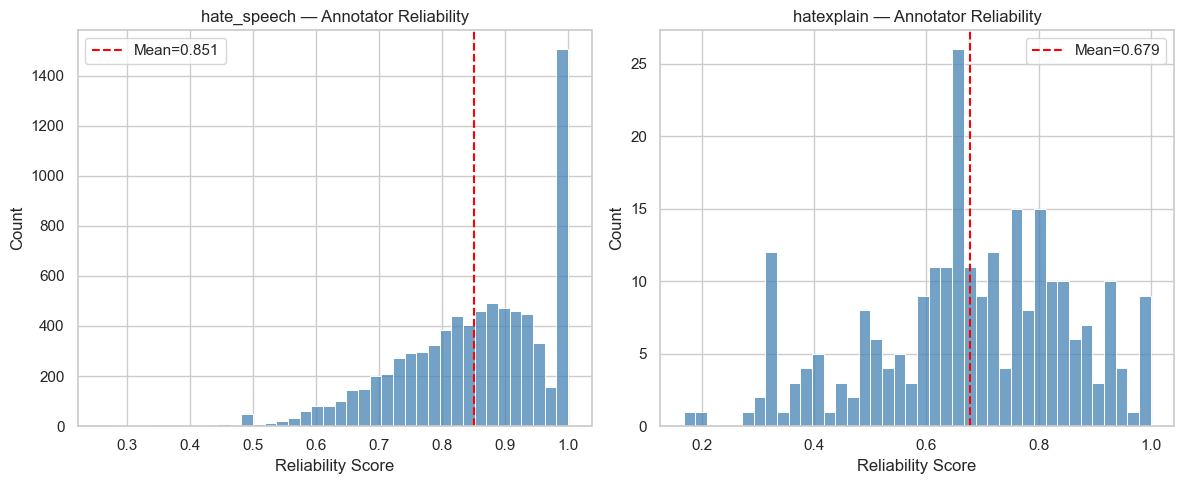

Saved: annotator_reliability.png


In [16]:
weights = results['annotator_weights']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, dataset in zip(axes, ['hate_speech', 'hatexplain']):
    subset = weights[weights['dataset'] == dataset]['reliability_score']
    sns.histplot(subset, bins=40, ax=ax, color='steelblue')
    ax.axvline(subset.mean(), color='red', linestyle='--', label=f'Mean={subset.mean():.3f}')
    ax.set_title(f'{dataset} — Annotator Reliability')
    ax.set_xlabel('Reliability Score')
    ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'annotator_reliability.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: annotator_reliability.png')

### Observation
- The reliability distribution reveals a spread of annotator quality across both datasets.
- Annotators with reliability scores near 1.0 are highly consistent; those near 1/K (random chance) contribute less signal.
- These weights are embedded in the soft labels and training dataset, so downstream models implicitly weight reliable annotators more heavily.

### 9b. Soft Label Confidence Distribution

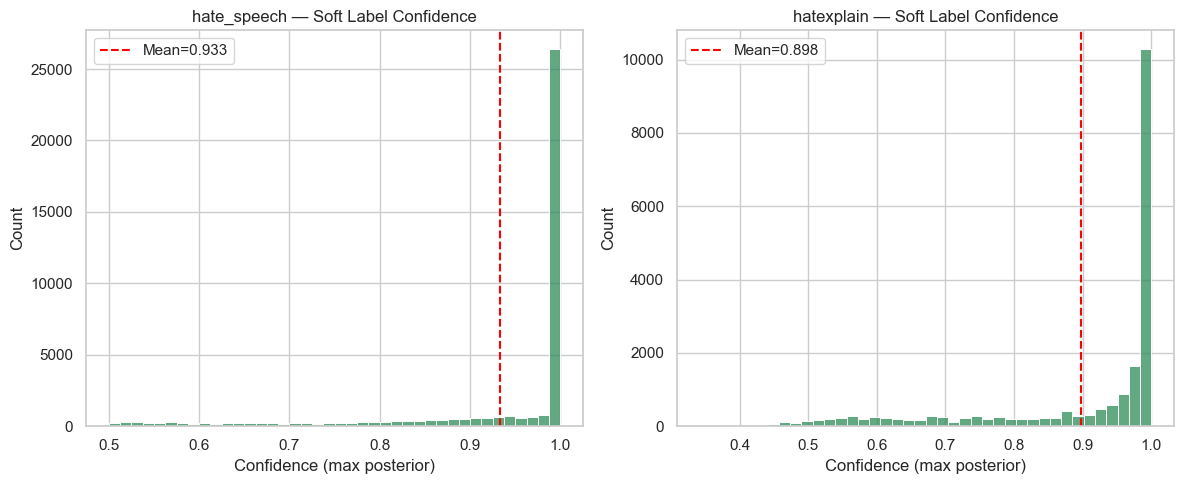

Saved: soft_label_confidence.png


In [17]:
soft = results['soft_labels']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, dataset in zip(axes, ['hate_speech', 'hatexplain']):
    subset = soft[soft['dataset'] == dataset]['confidence']
    sns.histplot(subset, bins=40, ax=ax, color='seagreen')
    ax.axvline(subset.mean(), color='red', linestyle='--', label=f'Mean={subset.mean():.3f}')
    ax.set_title(f'{dataset} — Soft Label Confidence')
    ax.set_xlabel('Confidence (max posterior)')
    ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'soft_label_confidence.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: soft_label_confidence.png')

### Observation
- High-confidence soft labels (confidence → 1.0) correspond to posts where annotators strongly agreed.
- Low-confidence items (confidence ≈ 0.5 for binary, 0.33 for 3-class) represent genuine disagreement — these are the hardest examples for any model.
- The `training_dataset.csv` retains the full probability vector, allowing Person B and C to train with soft targets rather than hard labels if desired.

### 9c. Training Dataset Preview

In [18]:
training = results['training_dataset']
print('Training dataset shape:', training.shape)
print('\nLabel breakdown:')
print(training['predicted_label'].value_counts())
print('\nSource breakdown:')
print(training['dataset_source'].value_counts())
display(training.head())

Training dataset shape: (59713, 12)

Label breakdown:
predicted_label
normal       37908
hate         18414
offensive     3391
Name: count, dtype: int64

Source breakdown:
dataset_source
hate_speech    39565
hatexplain     20148
Name: count, dtype: int64


,item_id,dataset_source,text,clean_text,text_length,word_count,majority_label,predicted_label,confidence,p_normal,p_offensive,p_hate
0,47777,hate_speech,Yes indeed. She sort of reminds me of the elde...,yes indeed she sort of reminds me of the elder...,239,51,normal,normal,1.000000,1.000000e+00,NaN,6.422661e-13
1,39773,hate_speech,The trans women reading this tweet right now i...,the trans women reading this tweet right now i...,57,10,normal,normal,1.000000,1.000000e+00,NaN,8.661139e-31
2,47101,hate_speech,Question: These 4 broads who criticize America...,question these 4 broads who criticize america ...,231,43,hate,hate,1.000000,8.242883e-22,NaN,1.000000e+00
3,43625,hate_speech,It is about time for all illegals to go back t...,it is about time for all illegals to go back t...,123,24,normal,normal,1.000000,1.000000e+00,NaN,2.018769e-09
4,12538,hate_speech,For starters bend over the one in pink and kic...,for starters bend over the one in pink and kic...,122,26,hate,normal,0.841507,8.415066e-01,NaN,1.584934e-01
